In [2]:
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [4]:
# 2. Load Dataset
# ===============================
df = pd.read_csv("/content/Titanic-Dataset.csv")

print(df.head())
print(df.info())
print(df.describe())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [5]:
# 3. Data Cleaning
# ===============================

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop unnecessary columns
df.drop(['Cabin'], axis=1, inplace=True)


/tmp/ipykernel_670/774851837.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_670/774851837.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

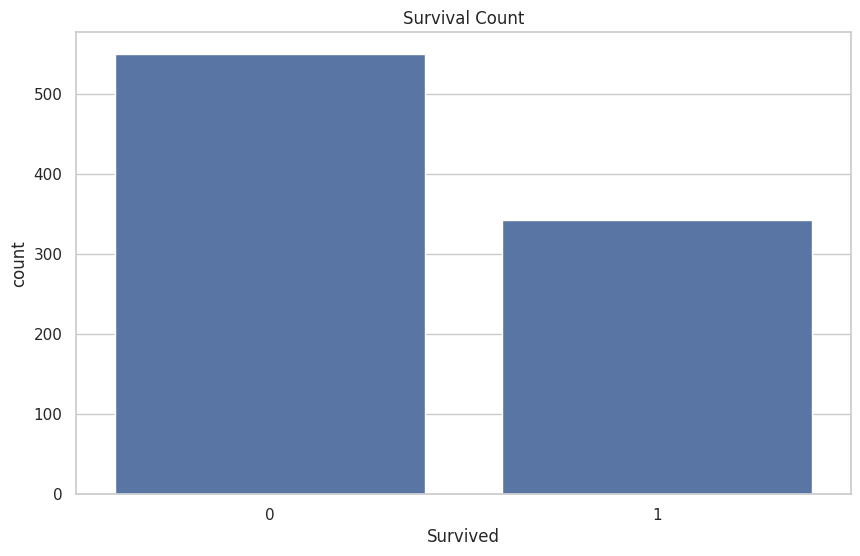

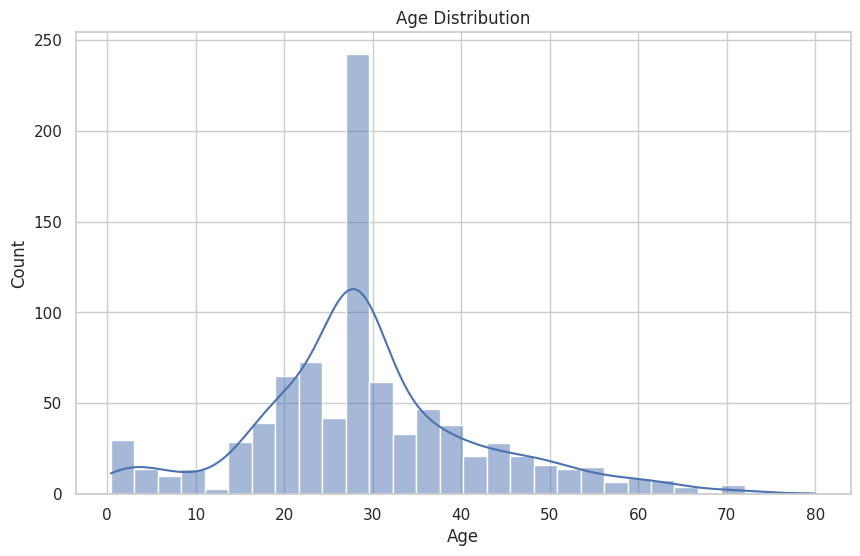

In [7]:
# 4. Univariate Analysis
# ===============================

# Survival count
sns.countplot(data=df, x='Survived')
plt.title("Survival Count")
plt.savefig("Survival_count.png", dpi=300, bbox_inches='tight')
plt.show()

# Age distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.savefig("Age_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

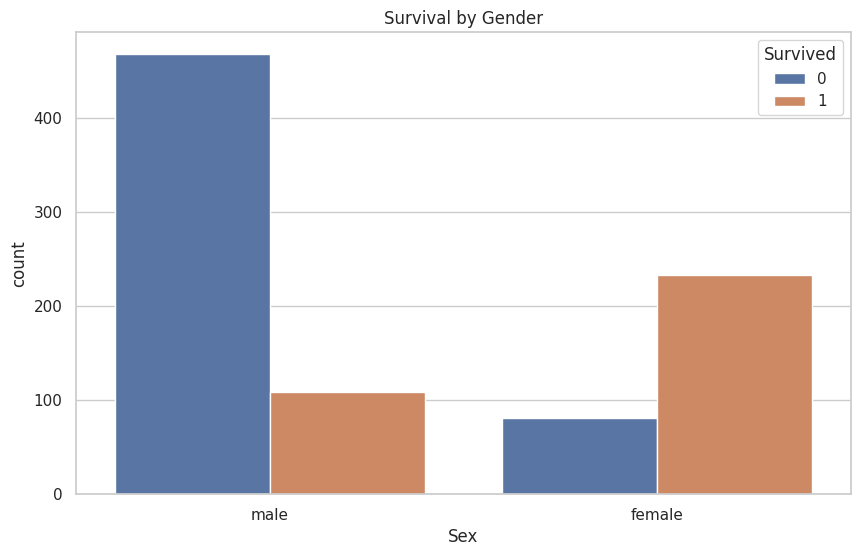

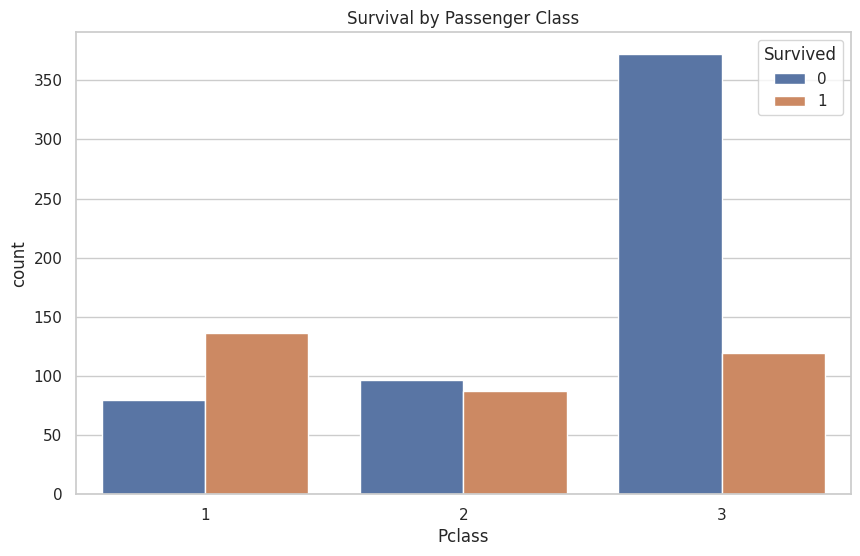

In [8]:
# 5. Bivariate Analysis
# ===============================

# Survival vs Gender
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival by Gender")
plt.savefig("Survival_by_gender.png", dpi=300, bbox_inches='tight')
plt.show()

# Survival vs Class
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Survival by Passenger Class")
plt.savefig("Survival_by_passenger_cls.png", dpi=300, bbox_inches='tight')
plt.show()


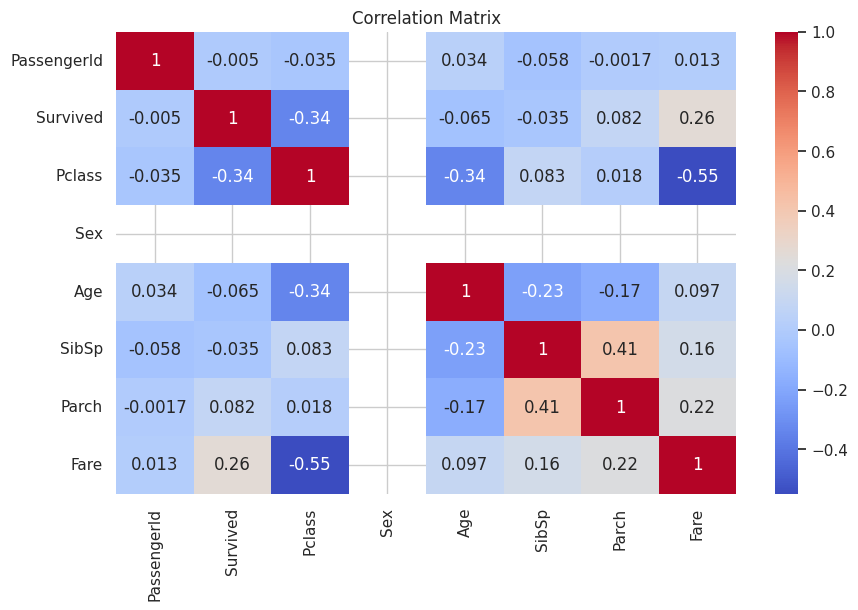

In [13]:
# 6. Correlation Analysis
# ===============================

# Convert categorical to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("Correlation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

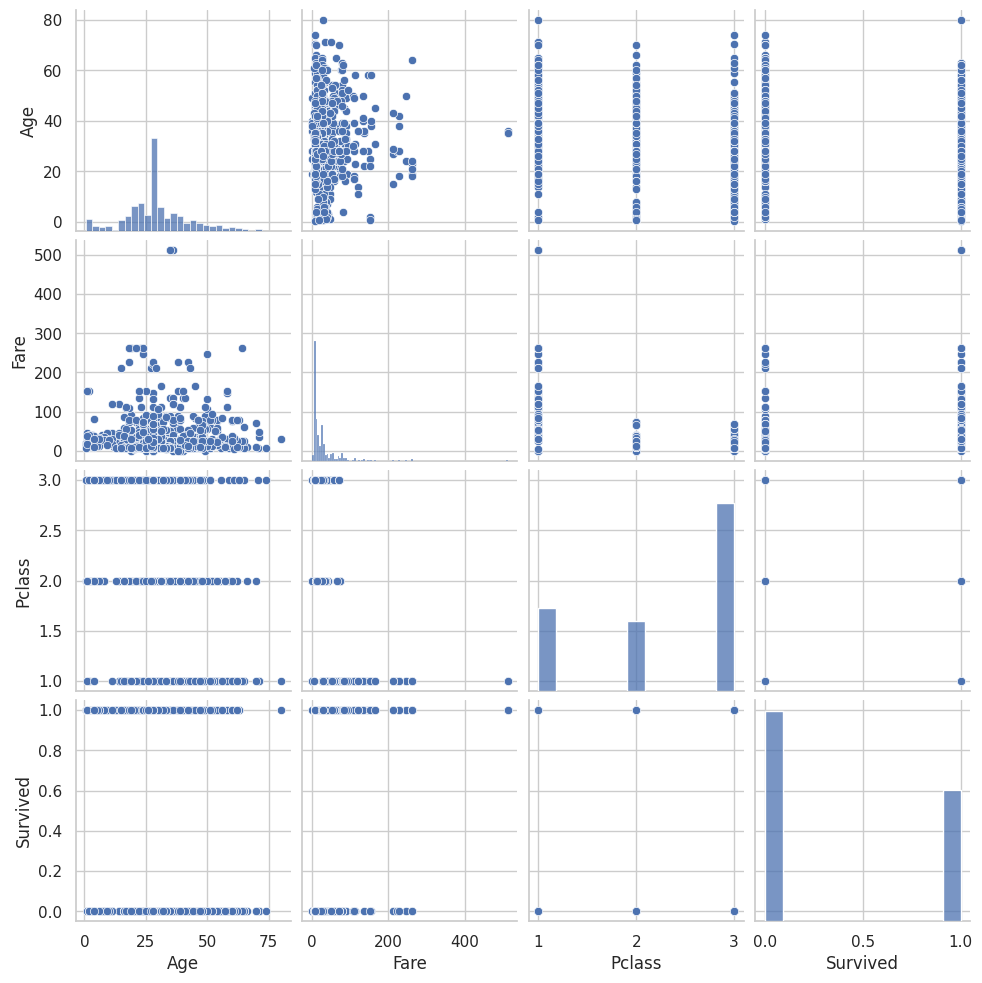

In [11]:
# 7. Multivariate Analysis
# ===============================

sns.pairplot(df[['Age','Fare','Pclass','Survived']])
plt.savefig("Multivariate_Analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# 8. Save Cleaned Data
# ===============================
df.to_csv("cleaned_titanic.csv", index=False)

print("EDA Completed!")

EDA Completed!
